In [2]:
import numpy as np

# Task 1: Creating a 5x5 matrix where border elements are 1 and interior is 0
matrix_border = np.ones((5, 5))
matrix_border[1:4, 1:4] = 0

print("Task 1:")
print(matrix_border)

# Task 2: Normalizing a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (
    random_data - random_data.mean(axis=0)
) / random_data.std(axis=0)

print("\nTask 2:")
print("Column means:")
print(normalized_data.mean(axis=0))

print("Column standard deviations:")
print(normalized_data.std(axis=0))

# Task 3:Implement linear regression solution using normal equation
X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y # I used the normal equation here

print("True coefficients:")
print(true_theta)

print("Estimated coefficients:")
print(theta_hat)

Task 1:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2:
Column means:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Column standard deviations:
[1. 1. 1.]

Task 3:
True coefficients:
[ 2.5 -1.2  3.7]
Estimated coefficients:
[ 2.51723721 -1.19783796  3.72399266]


In [4]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration

print("Information about dataset:")
df.info()

print("Missing Values:")
print(df.isnull().sum())

df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("Printing values: ")
print(df.isnull().sum())



# Task 2: Analysis

avg_scores = df.groupby('major')['exam_score'].mean()

print("Average Exam Score by Major:")
print(avg_scores)

print("Major with Highest Average Score:")
print(avg_scores.idxmax())

correlation = df['hours_studied'].corr(df['exam_score'])

print("Correlation between Hours Studied and Exam Score:")
print(correlation)

df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0, 70, 80, 90, 100],
    labels=['Needs Improvement', 'Average', 'Good', 'Excellent'],
    include_lowest=True
)

print("Performance Categories:")
print(df['performance'].value_counts())



# Task 3: Advanced Analysis

summary = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

print("Major-Year Summary:")
print(summary)

top5 = df.nlargest(5, 'exam_score')

print("Top 5 Students:")
print(top5[['student_id', 'major', 'exam_score']])

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("Pivot Table:")
print(pivot)

Information about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
Missing Values After Cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
d

In [9]:
print(df.head())

   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370


Information about dataset:


NameError: name 'df' is not defined

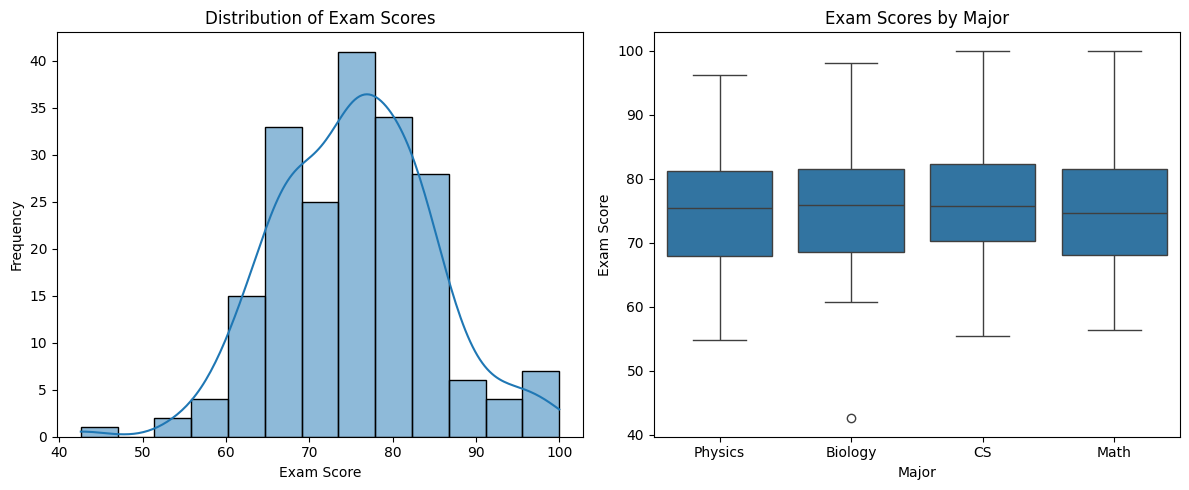

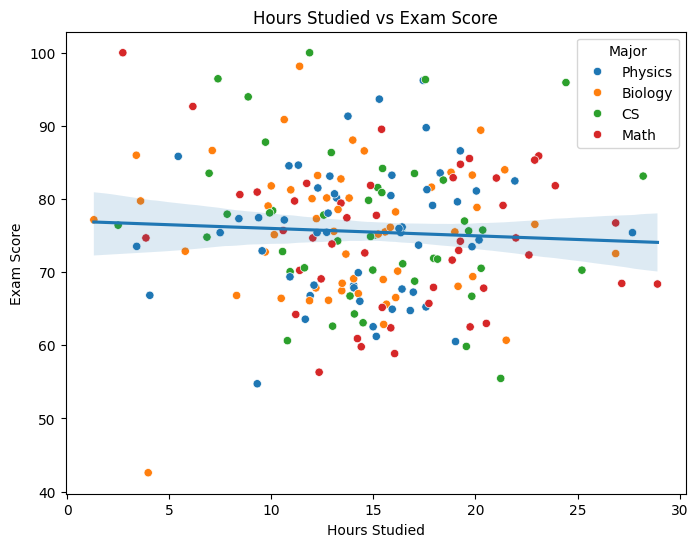

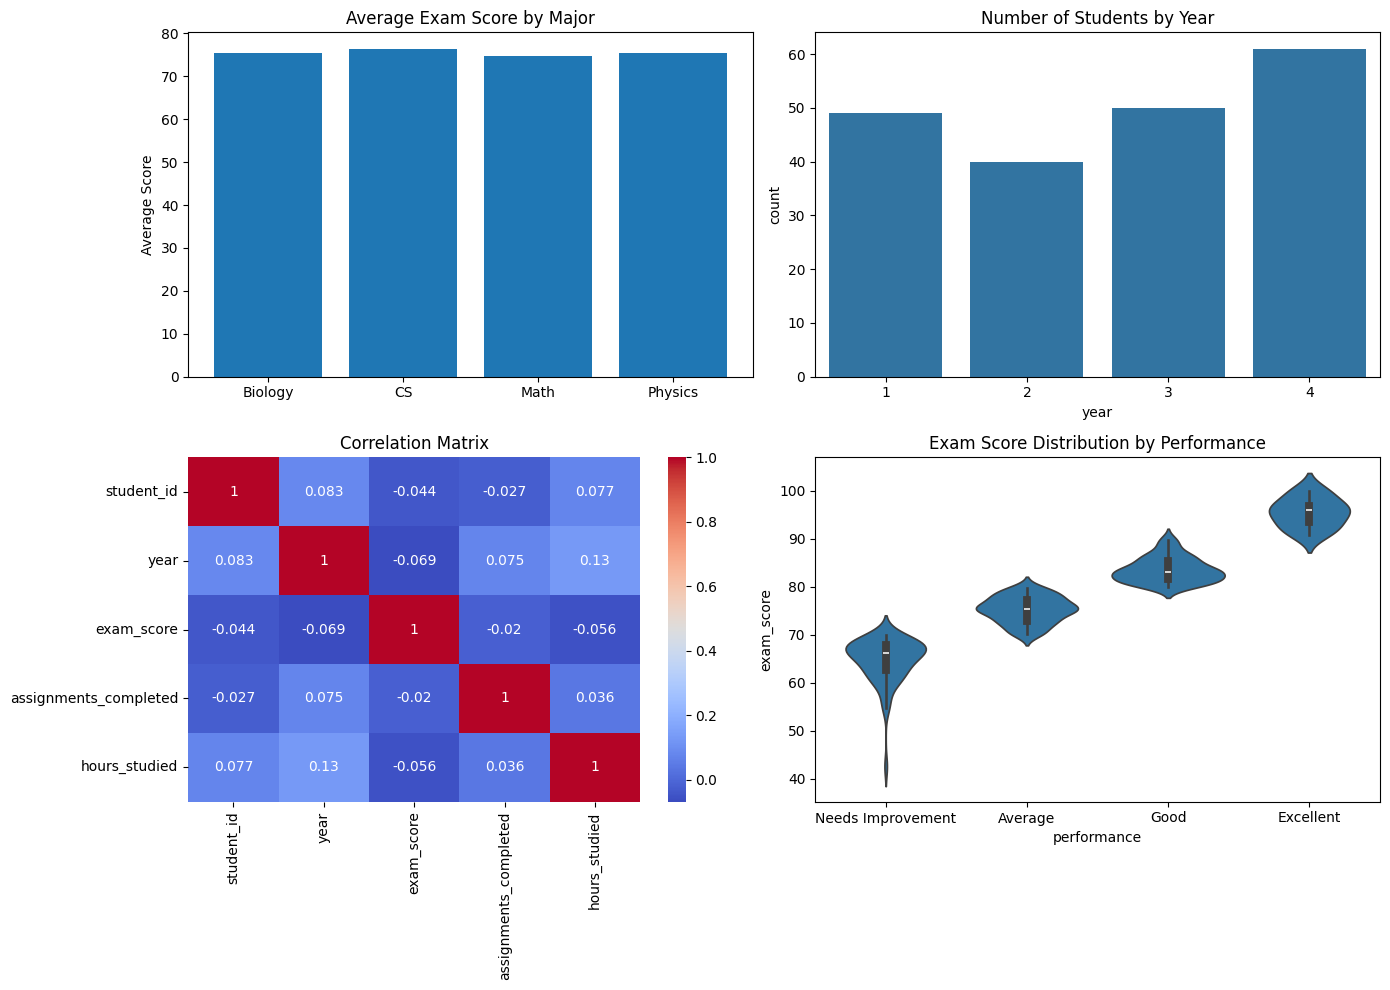

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with KDE overlay
sns.histplot(data=df, x='exam_score', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')

# Boxplot by major
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


# Task 2: Relationship Visualization

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Majors')
plt.show()


# Task 3: Advanced Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average score by major
avg_scores = df.groupby('major')['exam_score'].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_ylabel('Average Score')

# 2. Students by year
sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_title('Number of Students by Year')

# 3. Correlation heatmap
numeric_df = df.select_dtypes(include='number')
# to create a correlation heatmap i have to  use
#sns.heatmap(corr, annot=True)
#plt.show()

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Exam Score Distribution by Performance')

plt.tight_layout()
plt.show()

Age Group Summary
           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683

Top 10% Customers:
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663    

/tmp/ipykernel_621/1052219080.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = customers.groupby('age_group').agg(


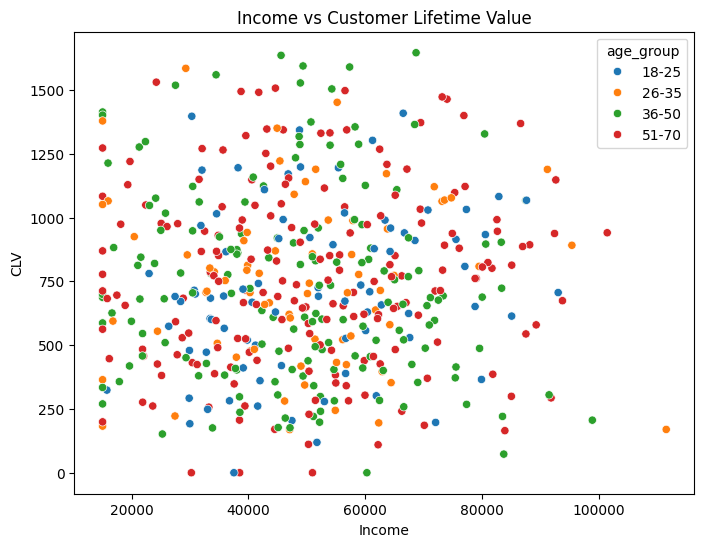

/tmp/ipykernel_621/1052219080.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


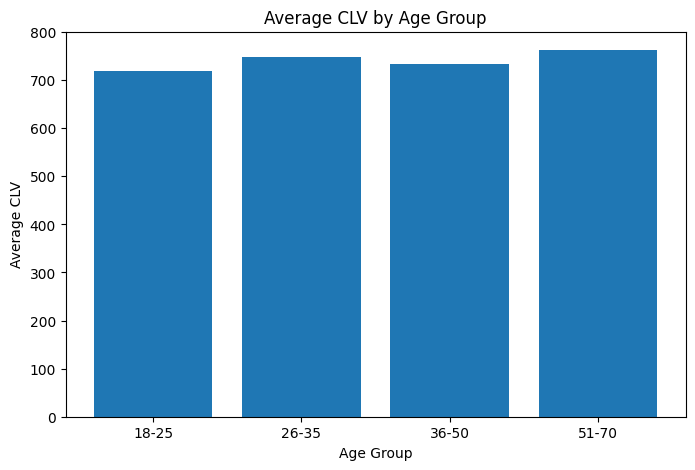

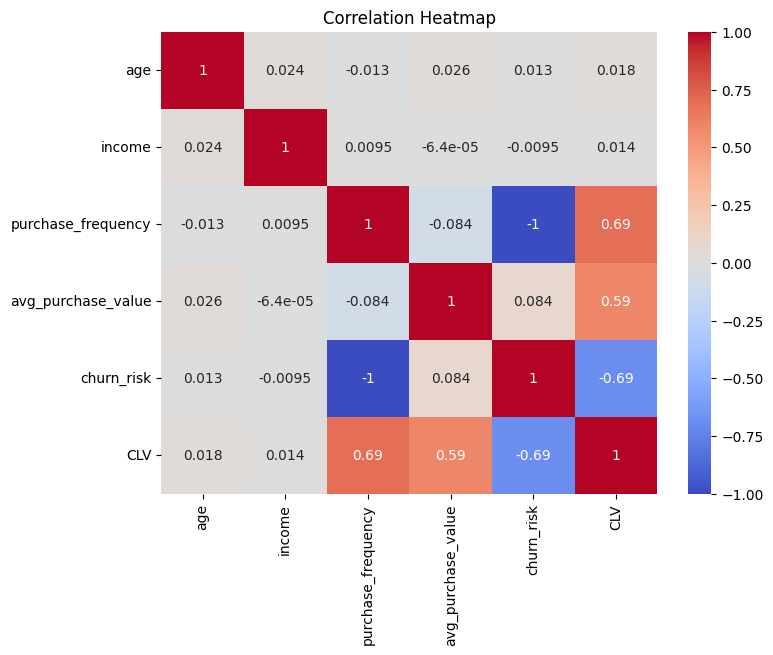

In [20]:

# Calculate CLV


max_frequency = customers['purchase_frequency'].max()#max frq

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency#formula for churn risk
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# Create Age Groups

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

# Analysis by Age Group


summary = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print("Age Group Summary")
print(summary)


# Top 10% Customers

threshold = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= threshold
]

print("Top 10% Customers:")
print(top_customers.head())

print(f"\nNumber of Top Customers: {len(top_customers)}")


# Visualization 1

# ScatterPlot(Income vs CLV)


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.show()

# Visualization 2
# Average CLV by Age Group

avg_clv = customers.groupby('age_group')['CLV'].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_clv.index.astype(str), avg_clv.values)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')
plt.show()


# Visualization 3

# Correlation Heatmap


plt.figure(figsize=(8, 6))

numeric_cols = customers.select_dtypes(include='number')

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [7]:
### Key Findings and Recommendations

"The analysis shows that students’ scores are slightly different across majors, but study time doesn’t really have a strong effect on performance."

'The analysis shows that students’ scores are slightly different across majors, but study time doesn’t really have a strong effect on performance.'